Este notebook sirve para la exploración inicial. Aquí van los gráficos descriptivos: distribución de clases, edad, colesterol, presión, frecuencia cardíaca, etc.

Código base del notebook:

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_cleveland, save_processed

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carga de datos:

In [2]:
df = load_cleveland()

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


Revisión general:

In [3]:
df.shape

(303, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
 14  source    303 non-null    str    
dtypes: float64(13), int64(1), str(1)
memory usage: 35.6 KB


In [5]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
source      0
dtype: int64

In [6]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

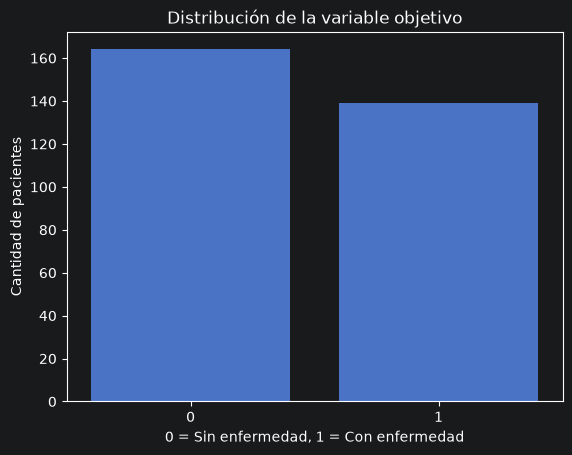

In [7]:
sns.countplot(data=df, x="target")
plt.title("Distribución de la variable objetivo")
plt.xlabel("0 = Sin enfermedad, 1 = Con enfermedad")
plt.ylabel("Cantidad de pacientes")
plt.show()

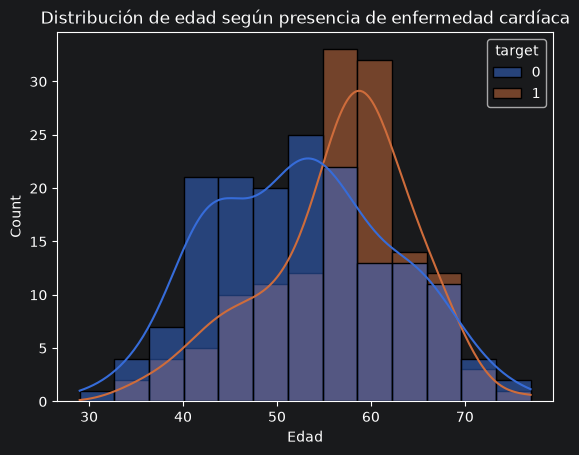

In [8]:
sns.histplot(data=df, x="age", hue="target", kde=True)
plt.title("Distribución de edad según presencia de enfermedad cardíaca")
plt.xlabel("Edad")
plt.show()

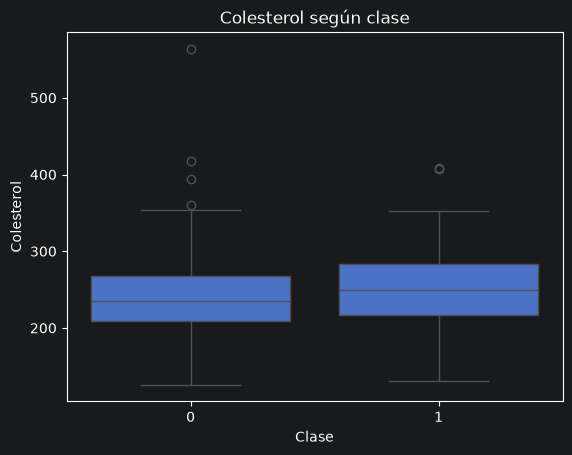

In [9]:
sns.boxplot(data=df, x="target", y="chol")
plt.title("Colesterol según clase")
plt.xlabel("Clase")
plt.ylabel("Colesterol")
plt.show()

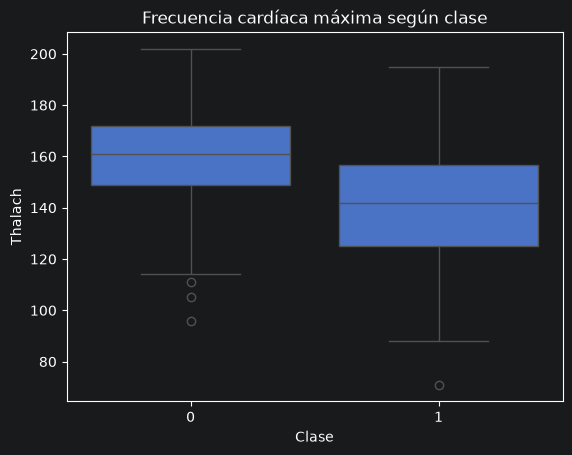

In [10]:
sns.boxplot(data=df, x="target", y="thalach")
plt.title("Frecuencia cardíaca máxima según clase")
plt.xlabel("Clase")
plt.ylabel("Thalach")
plt.show()

Guardar versión procesada básica:

In [11]:
df_model = df.drop(columns=["source"])
save_processed(df_model, "cleveland_clean.csv")

WindowsPath('C:/Users/xenci/PycharmProjects/heart-risk-ai/data/processed/cleveland_clean.csv')